# iForge SLA Printer Bookings — In-Semester Analysis

Compares booked SLA hours (Formlabs vs Anycubic) for **2025-26 vs 2024-25**, restricted to in-semester weeks only.

The source xlsx contains booking data from 2024-10-04 onward; 2023-24 is not present, so the comparison is over the two academic years for which we have data.

Semester windows are taken verbatim from the published UoS academic calendar dates supplied by the user. Welcome week is excluded. Each academic year is contiguous: A1 weeks 1–12, A2 weeks 13–15, S1 weeks 16–22/23, S2 weeks 23/24–30 (30 in-semester weeks total per year).

**Metric:** total booked hours per week, where hours = `Duration.total_seconds() / 3600`, **capped at 10 h per booking** to suppress data-entry outliers (e.g. ~1300 h slots). Each row in the booking sheet is one slot (mostly 4 h short builds, with some overnight slots that the cap also clips).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, datetime, timedelta

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

/Users/franklinshen/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/franklinshen/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Semester windows

Each block is `(label, start_date, end_date_inclusive, declared_weeks)`. The block week index for a date `d` is `((d - start).days // 7) + 1`, and the across-season week index is `sum(prev_block_weeks) + block_week`.

In [2]:
SEMESTERS = {
    '2024-25': [
        ('A1', date(2024, 9, 30),  date(2024, 12, 21), 12),
        ('A2', date(2025, 1, 20),  date(2025, 2, 8),    3),
        ('S1', date(2025, 2, 10),  date(2025, 4, 5),    8),
        ('S2', date(2025, 4, 28),  date(2025, 6, 14),   7),
    ],
    '2025-26': [
        ('A1', date(2025, 9, 29),  date(2025, 12, 20), 12),
        ('A2', date(2026, 1, 19),  date(2026, 2, 7),    3),
        ('S1', date(2026, 2, 9),   date(2026, 3, 28),   7),
        ('S2', date(2026, 4, 20),  date(2026, 6, 13),   8),
    ],
}

HOURS_CAP = 10.0

def assign_semester_week(d):
    """Return (academic_year, season_week 1..30) for date d, or (None, None) if out of semester."""
    if isinstance(d, datetime):
        d = d.date()
    for year, blocks in SEMESTERS.items():
        cum = 0
        for label, start, end, n_weeks in blocks:
            if start <= d <= end:
                wk = ((d - start).days // 7) + 1
                wk = min(wk, n_weeks)
                return year, cum + wk
            cum += n_weeks
    return None, None

# Sanity check
for d in [date(2025, 9, 29), date(2025, 12, 20), date(2026, 1, 19), date(2026, 2, 9), date(2026, 4, 20), date(2026, 6, 13), date(2025, 12, 25)]:
    print(d, '->', assign_semester_week(d))


2025-09-29 -> ('2025-26', 1)
2025-12-20 -> ('2025-26', 12)
2026-01-19 -> ('2025-26', 13)
2026-02-09 -> ('2025-26', 16)
2026-04-20 -> ('2025-26', 23)
2026-06-13 -> ('2025-26', 30)
2025-12-25 -> (None, None)


## 2. Load and parse bookings

In [3]:
XLSX = 'iForge SLA printer booking.xlsx'
raw = pd.read_excel(XLSX, sheet_name=0)
print('Columns:', list(raw.columns))
print('Rows:', len(raw))
raw.head(3)

Columns: ['\n    ', 'Project', 'Text', 'Weekday', 'Date', 'Start time', 'Duration', 'Day accumulated', 'Location', 'Description', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']
Rows: 339


,\n,Project,Text,Weekday,Date,Start time,Duration,Day accumulated,Location,Description,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,iForge SLA Formlabs,SLA Formlabs (Laura Mason),Friday,2024-10-04,2024-10-04 16:00:00,0 days 04:00:00,4:00:00,"iForge Heartspace, Sir Frederick Mappin Buildi...",<b>Booked by</b>\nLaura Mason\nlaura.mason@she...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,iForge SLA Formlabs,SLA Formlabs (James Hilton-Balfe),Friday,2024-10-04,2024-10-04 16:00:00,0 days 04:00:00,8:00:00,"iForge Heartspace, Sir Frederick Mappin Buildi...",<b>Booked by</b>\nJames Hilton-Balfe\njhilton-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,iForge SLA Anycubic,SLA Anycubic (Laura Mason),Friday,2024-10-04,2024-10-04 16:00:00,0 days 04:00:00,12:00:00,"iForge Heartspace, Sir Frederick Mappin Buildi...",<b>Booked by</b>\nLaura Mason\nlaura.mason@she...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = raw.copy()

def to_date(v):
    if pd.isna(v):
        return pd.NaT
    if isinstance(v, (pd.Timestamp, datetime)):
        return pd.Timestamp(v).normalize()
    return pd.Timestamp('1899-12-30') + pd.to_timedelta(float(v), unit='D')

def to_hours(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, pd.Timedelta):
        return v.total_seconds() / 3600.0
    return float(v) * 24.0

df['date'] = df['Date'].apply(to_date)
df['hours_raw'] = df['Duration'].apply(to_hours)
df['hours'] = df['hours_raw'].clip(upper=HOURS_CAP)

# Printer: Formlabs / Anycubic from Project
df['printer'] = df['Project'].str.extract(r'(Formlabs|Anycubic)', expand=False)

# Assign semester week
sw = df['date'].apply(lambda x: assign_semester_week(x) if pd.notna(x) else (None, None))
df['academic_year'] = sw.apply(lambda x: x[0])
df['season_week'] = sw.apply(lambda x: x[1])

n_clipped = ((df['hours_raw'] > HOURS_CAP) & df['hours_raw'].notna()).sum()
print(f'Total bookings: {len(df)}')
print(f'Date range in file: {df.date.min().date()} -> {df.date.max().date()}')
print(f'Bookings clipped by {HOURS_CAP}h cap: {n_clipped}')
print('Hours per booking after cap:')
print(df['hours'].dropna().describe().round(2))
print('\nIn-semester bookings by year:')
print(df[df['academic_year'].notna()].groupby('academic_year').size())
print(f"\nDropped (out of semester / unidentified printer): {df['academic_year'].isna().sum()}")


Total bookings: 339
Date range in file: 2024-10-04 -> 2026-05-14
Bookings clipped by 10.0h cap: 1
Hours per booking after cap:
count    328.00
mean       4.02
std        0.33
min        4.00
25%        4.00
50%        4.00
75%        4.00
max       10.00
Name: hours, dtype: float64

In-semester bookings by year:
academic_year
2024-25    141
2025-26    158
dtype: int64

Dropped (out of semester / unidentified printer): 40


In [5]:
in_sem = df[df['academic_year'].notna() & df['printer'].notna()].copy()
in_sem['season_week'] = in_sem['season_week'].astype(int)

# Last actual data date overall, and per year — flag partial years
today = pd.Timestamp(date.today())
max_date = df['date'].max()
print('Today:', today.date(), ' | max booking date in file:', max_date.date())
for y in ['2023-24', '2024-25', '2025-26']:
    sub = in_sem[in_sem['academic_year'] == y]
    if len(sub):
        print(f'  {y}: weeks {sub.season_week.min()}–{sub.season_week.max()}, {len(sub)} bookings, {sub.hours.sum():.1f} h')

Today: 2026-05-18  | max booking date in file: 2026-05-14
  2024-25: weeks 1–30, 141 bookings, 564.0 h
  2025-26: weeks 3–26, 158 bookings, 632.0 h


## 3. Weekly hours per printer per year

In [6]:
# Full grid: every (year, week 1..30, printer) so missing weeks show as 0
years = ['2024-25', '2025-26']
printers = ['Formlabs', 'Anycubic']
grid = pd.MultiIndex.from_product([years, range(1, 31), printers],
                                  names=['academic_year', 'season_week', 'printer']).to_frame(index=False)

weekly = (in_sem.groupby(['academic_year', 'season_week', 'printer'], as_index=False)['hours']
                .sum()
                .merge(grid, on=['academic_year', 'season_week', 'printer'], how='right')
                .fillna({'hours': 0.0}))

pivot_hours = weekly.pivot_table(index='season_week', columns=['printer', 'academic_year'],
                                  values='hours', aggfunc='sum').fillna(0.0)
pivot_hours.head()


printer       Anycubic         Formlabs        
academic_year  2024-25 2025-26  2024-25 2025-26
season_week                                    
1                  8.0     0.0      8.0     0.0
2                  0.0     0.0      4.0     0.0
3                  0.0     0.0      4.0     8.0
4                  0.0     0.0      4.0     4.0
5                  0.0     0.0      8.0     4.0

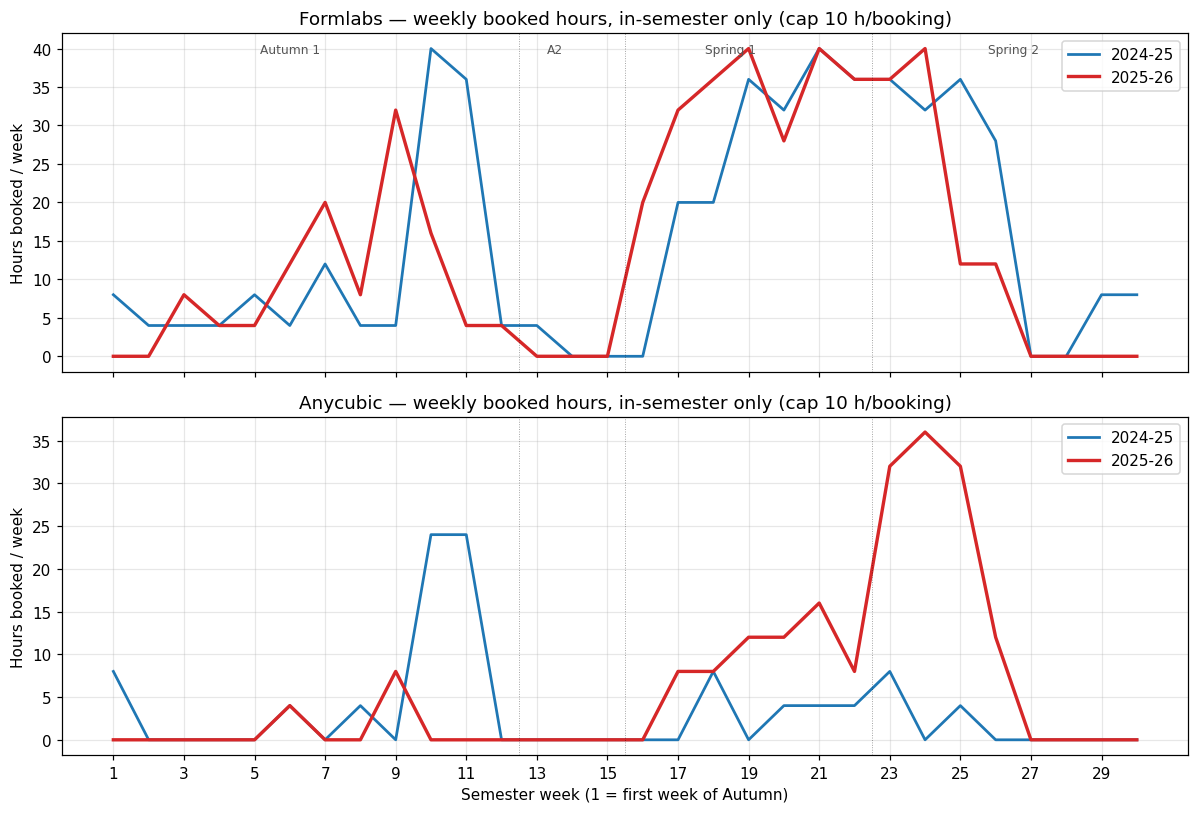

In [7]:
# Block boundaries (for vertical guides between A1/A2/S1/S2)
BLOCK_EDGES = [(12, 'A1 / A2'), (15, 'A2 / S1'), (22, 'S1 / S2')]
BLOCK_CENTERS = [(6, 'Autumn 1'), (13.5, 'A2'), (18.5, 'Spring 1'), (26.5, 'Spring 2')]
YEAR_STYLE = {'2024-25': dict(color='#1f77b4', lw=1.8, ls='-'),
              '2025-26': dict(color='#d62728', lw=2.2, ls='-')}

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for ax, printer in zip(axes, printers):
    for y in years:
        s = pivot_hours[(printer, y)] if (printer, y) in pivot_hours.columns else pd.Series(0.0, index=range(1, 31))
        ax.plot(s.index, s.values, label=y, **YEAR_STYLE[y])
    for x, _ in BLOCK_EDGES:
        ax.axvline(x + 0.5, color='k', lw=0.6, ls=':', alpha=0.4)
    ax.set_title(f'{printer} — weekly booked hours, in-semester only (cap {HOURS_CAP:.0f} h/booking)')
    ax.set_ylabel('Hours booked / week')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Semester week (1 = first week of Autumn)')
axes[-1].set_xticks(range(1, 31, 2))
for x, lbl in BLOCK_CENTERS:
    axes[0].text(x, axes[0].get_ylim()[1] * 0.97, lbl, ha='center', va='top', fontsize=8, color='#555')
plt.tight_layout()
plt.show()


## 4. Cumulative hours through the season

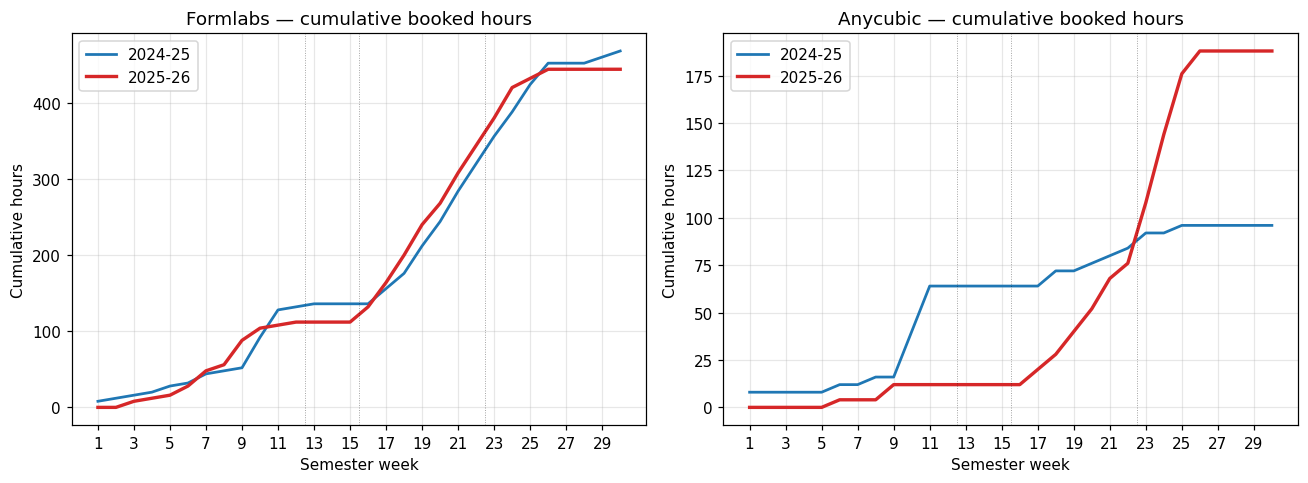

In [8]:
cum = pivot_hours.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, printer in zip(axes, printers):
    for y in years:
        s = cum[(printer, y)] if (printer, y) in cum.columns else pd.Series(0.0, index=range(1, 31))
        ax.plot(s.index, s.values, label=y, **YEAR_STYLE[y])
    for x, _ in BLOCK_EDGES:
        ax.axvline(x + 0.5, color='k', lw=0.6, ls=':', alpha=0.4)
    ax.set_title(f'{printer} — cumulative booked hours')
    ax.set_xlabel('Semester week')
    ax.set_ylabel('Cumulative hours')
    ax.legend(loc='upper left')
    ax.set_xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

## 5. Like-for-like: this year vs same number of weeks of prior years

Because 2025-26 is partial (today is mid-Spring 2), comparing full-season totals against prior years would understate this year. Here we cap each prior year at the same season week that 25-26 has reached, so totals are directly comparable.

In [9]:
current_year = '2025-26'
_, today_week = assign_semester_week(date.today())
if today_week is None:
    # Today is in vacation — use max season_week observed in current year instead
    today_week = int(in_sem.loc[in_sem.academic_year == current_year, 'season_week'].max())
print(f'Comparison cap: season week {today_week} (today = {date.today()})')

rows = []
for printer in printers:
    for y in years:
        s = pivot_hours[(printer, y)] if (printer, y) in pivot_hours.columns else pd.Series(0.0, index=range(1, 31))
        rows.append({
            'printer': printer,
            'year': y,
            f'hours_through_wk{today_week}': float(s.loc[:today_week].sum()),
            'hours_full_season': float(s.sum()),
            'bookings_in_sem': int(((in_sem.academic_year == y) & (in_sem.printer == printer)).sum()),
        })
summary = pd.DataFrame(rows)
summary

Comparison cap: season week 27 (today = 2026-05-18)


,printer,year,hours_through_wk27,hours_full_season,bookings_in_sem
0,Formlabs,2024-25,452.0,468.0,117
1,Formlabs,2025-26,444.0,444.0,111
2,Anycubic,2024-25,96.0,96.0,24
3,Anycubic,2025-26,188.0,188.0,47


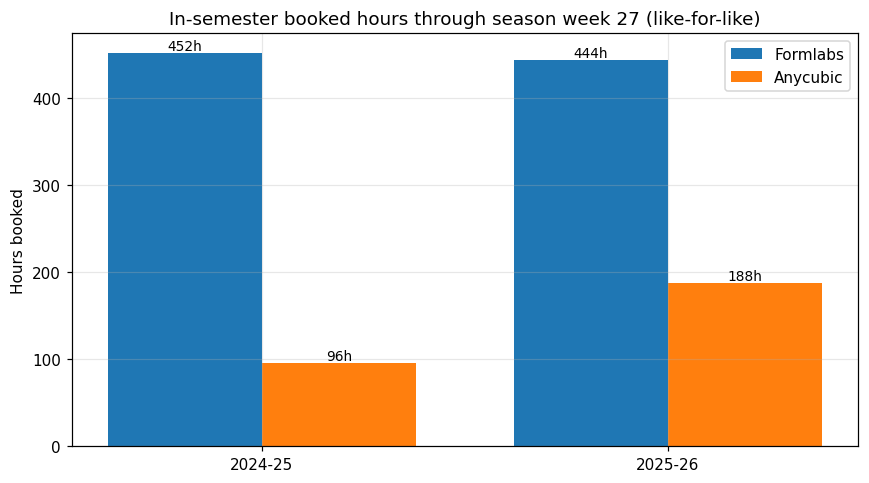

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(years))
width = 0.38
for i, printer in enumerate(printers):
    vals = [summary.loc[(summary.printer == printer) & (summary.year == y), f'hours_through_wk{today_week}'].iloc[0] for y in years]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=printer)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.0f}h', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Hours booked')
ax.set_title(f'In-semester booked hours through season week {today_week} (like-for-like)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Year-on-year deltas

In [11]:
ytd_col = f'hours_through_wk{today_week}'
wide = summary.pivot(index='printer', columns='year', values=ytd_col)
wide['Δ vs 24-25'] = wide['2025-26'] - wide['2024-25']
wide['Δ vs 24-25 %'] = (wide['2025-26'] / wide['2024-25'].replace(0, np.nan) - 1) * 100
wide.round(1)


year,2024-25,2025-26,Δ vs 24-25,Δ vs 24-25 %
printer,,,,
Anycubic,96.0,188.0,92.0,95.8
Formlabs,452.0,444.0,-8.0,-1.8


In [12]:
# Combined (both printers) totals
combined = (in_sem.assign(through_today=lambda d: d.season_week <= today_week)
                   .groupby('academic_year')
                   .apply(lambda g: pd.Series({
                       'hours_full_season': g['hours'].sum(),
                       f'hours_through_wk{today_week}': g.loc[g.through_today, 'hours'].sum(),
                       'bookings_full_season': len(g),
                       f'bookings_through_wk{today_week}': int(g.through_today.sum()),
                       'unique_users': g['Description'].str.extract(r'([\w.+-]+@[\w.-]+)', expand=False).nunique(),
                   })))
combined.round(1)

,hours_full_season,hours_through_wk27,bookings_full_season,bookings_through_wk27,unique_users
academic_year,,,,,
2024-25,564.0,548.0,141.0,137.0,31.0
2025-26,632.0,632.0,158.0,158.0,38.0


## 8. Uptime ratio — bookings vs available slots

**Capacity model:** 2 slots/day (12:00–16:00 short build, 16:00–20:00 longer / overnight), weekdays only, in-semester only.

For each (year, printer):
- `capacity` = (in-semester weekdays) × 2
- `bookings` = number of in-semester **weekday** bookings for that printer
- `uptime_%` = bookings / capacity × 100

A full year has 150 in-semester weekdays → 300 slots per printer → 600 slots across both printers. The like-for-like view caps both years at the same season-week as 2025-26 reached today.


In [13]:
SLOTS_PER_DAY = 2  # 12:00-16:00 and 16:00-20:00

def iter_in_sem_weekdays(year):
    """Yield each in-semester weekday for `year` in chronological order."""
    for label, start, end, _ in SEMESTERS[year]:
        d = start
        while d <= end:
            if d.weekday() < 5:
                yield d
            d += timedelta(days=1)

def weekdays_through(year, max_date):
    return sum(1 for d in iter_in_sem_weekdays(year) if d <= max_date)

def date_after_n_weekdays(year, n):
    """The date of the n-th in-semester weekday of `year` (1-indexed). Returns None if not reached."""
    for i, d in enumerate(iter_in_sem_weekdays(year), start=1):
        if i == n:
            return d
    return None

# Restrict bookings to in-semester weekdays only (consistent with capacity model)
wd_bookings = in_sem[in_sem['date'].dt.dayofweek < 5].copy()

# True like-for-like: count weekdays *elapsed* in 25-26 up to today, then take the same number from 24-25.
today_d = date.today()
elapsed_25_26 = weekdays_through('2025-26', today_d)
ll_end_24_25 = date_after_n_weekdays('2024-25', elapsed_25_26)
print(f"Today: {today_d} | elapsed in-semester weekdays in 25-26: {elapsed_25_26}")
print(f"Like-for-like cutoff in 24-25: {ll_end_24_25} ({elapsed_25_26}-th in-sem weekday)")

cutoff = {'2024-25': ll_end_24_25, '2025-26': today_d}

# Per-printer per-year uptime: full season AND like-for-like through `cutoff[year]`
rows = []
for y in years:
    wd_full = sum(1 for _ in iter_in_sem_weekdays(y))
    cap_full = wd_full * SLOTS_PER_DAY
    wd_ll   = weekdays_through(y, cutoff[y])
    cap_ll  = wd_ll * SLOTS_PER_DAY
    for p in printers:
        sub = wd_bookings[(wd_bookings.academic_year == y) & (wd_bookings.printer == p)]
        b_full = len(sub)
        b_ll = len(sub[sub['date'].dt.date <= cutoff[y]])
        rows.append({
            'year': y, 'printer': p,
            'weekdays_full': wd_full, 'capacity_full': cap_full,
            'bookings_full': b_full,
            'uptime_full_%': round(100 * b_full / cap_full, 1),
            'weekdays_LL': wd_ll, 'capacity_LL': cap_ll,
            'bookings_LL': b_ll,
            'uptime_LL_%': round(100 * b_ll / cap_ll, 1),
        })
uptime_df = pd.DataFrame(rows).set_index(['year', 'printer'])
print('\nPer-printer uptime (LL = like-for-like through same elapsed weekday):')
uptime_df


Today: 2026-05-18 | elapsed in-semester weekdays in 25-26: 131
Like-for-like cutoff in 24-25: 2025-05-19 (131-th in-sem weekday)

Per-printer uptime (LL = like-for-like through same elapsed weekday):


weekdays_full  capacity_full  bookings_full  uptime_full_%  \
year    printer                                                                
2024-25 Formlabs            150            300            117           39.0   
        Anycubic            150            300             24            8.0   
2025-26 Formlabs            150            300            111           37.0   
        Anycubic            150            300             47           15.7   

                  weekdays_LL  capacity_LL  bookings_LL  uptime_LL_%  
year    printer                                                       
2024-25 Formlabs          131          262          113         43.1  
        Anycubic          131          262           24          9.2  
2025-26 Formlabs          131          262          111         42.4  
        Anycubic          131          262           47         17.9

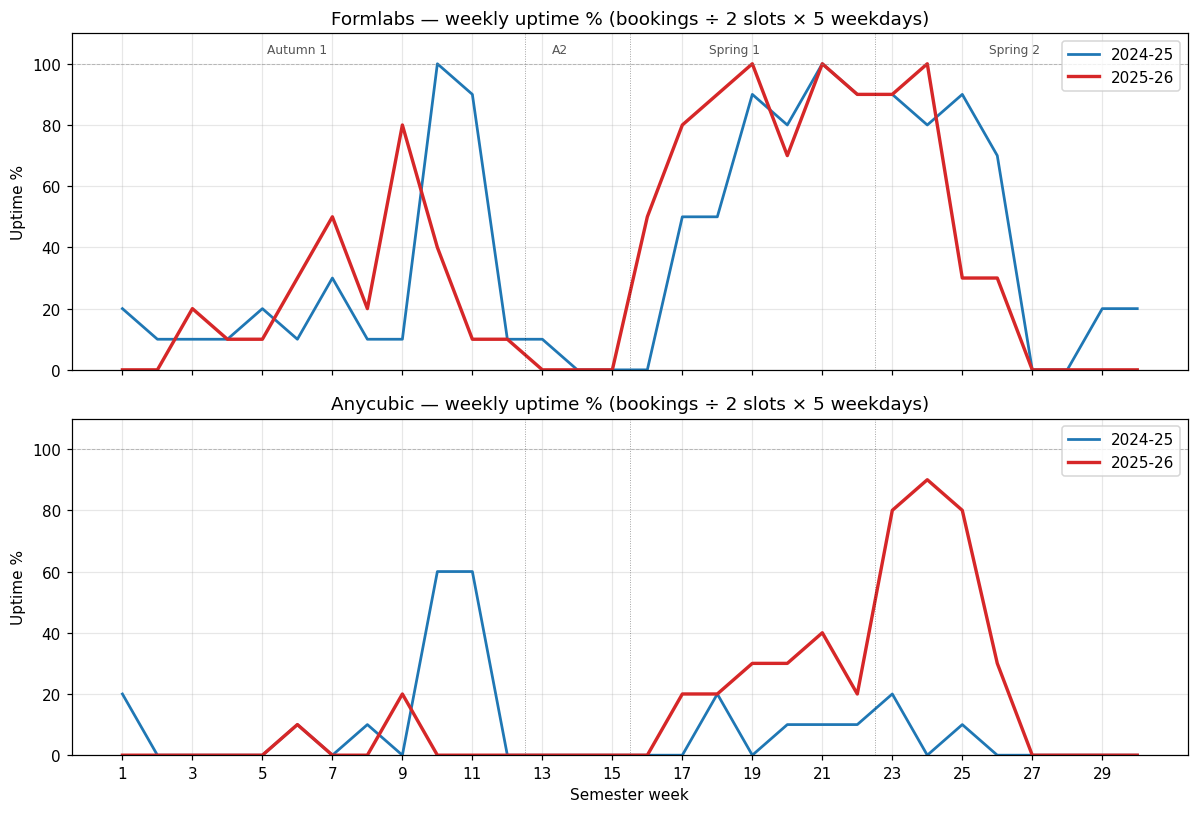

In [14]:
# Weekly uptime % time series, per printer per year
wk_caps_dict = {}
for y, blocks in SEMESTERS.items():
    cum = 0
    for label, start, end, n_weeks in blocks:
        d = start
        while d <= end:
            if d.weekday() < 5:
                wk = min(((d - start).days // 7) + 1, n_weeks)
                wk_caps_dict[(y, cum + wk)] = wk_caps_dict.get((y, cum + wk), 0) + 1
            d += timedelta(days=1)
        cum += n_weeks
caps_df = pd.DataFrame([{'academic_year': y, 'season_week': w, 'weekdays': wd,
                        'capacity_per_printer': wd * SLOTS_PER_DAY}
                       for (y, w), wd in wk_caps_dict.items()])

weekly_bk = (wd_bookings.groupby(['academic_year', 'season_week', 'printer'], as_index=False)
                        .size()
                        .rename(columns={'size': 'bookings'}))
grid2 = pd.MultiIndex.from_product([years, range(1, 31), printers],
                                   names=['academic_year', 'season_week', 'printer']).to_frame(index=False)
weekly_uptime = (grid2.merge(weekly_bk, on=['academic_year', 'season_week', 'printer'], how='left')
                      .merge(caps_df[['academic_year', 'season_week', 'capacity_per_printer']],
                             on=['academic_year', 'season_week'], how='left')
                      .fillna({'bookings': 0}))
weekly_uptime['uptime_%'] = 100 * weekly_uptime['bookings'] / weekly_uptime['capacity_per_printer']

# Plot
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for ax, printer in zip(axes, printers):
    for y in years:
        s = (weekly_uptime[(weekly_uptime.printer == printer) & (weekly_uptime.academic_year == y)]
             .set_index('season_week')['uptime_%'])
        ax.plot(s.index, s.values, label=y, **YEAR_STYLE[y])
    for x, _ in BLOCK_EDGES:
        ax.axvline(x + 0.5, color='k', lw=0.6, ls=':', alpha=0.4)
    ax.axhline(100, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax.set_title(f'{printer} — weekly uptime % (bookings ÷ {SLOTS_PER_DAY} slots × 5 weekdays)')
    ax.set_ylabel('Uptime %')
    ax.set_ylim(0, max(110, weekly_uptime['uptime_%'].max() * 1.1))
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Semester week')
axes[-1].set_xticks(range(1, 31, 2))
for x, lbl in BLOCK_CENTERS:
    axes[0].text(x, axes[0].get_ylim()[1] * 0.97, lbl, ha='center', va='top', fontsize=8, color='#555')
plt.tight_layout()
plt.show()


## 9. Notes & caveats

- **2025-26 is partial** — today maps to a season week of 30. Sections 5/6/8 normalise 2024-25 to the same week so totals are like-for-like.
- **2023-24 not in source file** (earliest booking 2024-10-04). Comparison is 25-26 vs 24-25 only.
- **`HOURS_CAP = 10 h`** is applied to every booking before summing. The raw data contains a handful of bookings with implausibly long durations (≥1 day); capping at 10 h preserves overnight slots while suppressing the outliers. Change `HOURS_CAP` in cell 3 to adjust.
- **Uptime model (section 8)** counts each booking as 1 slot occupied. Capacity = `SLOTS_PER_DAY × in-semester weekdays`. Weekend bookings (if any) are excluded so numerator and denominator are on the same calendar. If a slot was double-booked or split this would still count as 1.
- Bookings dated outside the four in-semester blocks (welcome week, Christmas/Easter vacation, summer) are dropped.
- Block week is capped at the declared total per block (12 / 3 / 7-8 / 8-7), so a date on the final day of a block is the last week of that block, never overflow.
